In [1]:
import numpy as np
from scipy.special import gamma, gammaincc
from scipy.optimize import root_scalar

In [32]:
R_input_1 = 2/3600 # Rainfall rate [kg/m2/s] (if in [mm/h] divide by 3600)
R_input_2 = 10/3600
R_input_3 = 40/3600 # Rainfall rate [kg/m2/s]
v = 200# [cm/s]
Dc = 0.08 # Critical drop diameter for evaporation[cm]

#### Functions

In [33]:
# --- Parameters of empirical mu(Lambda) relation ---
def mu_from_lambda(Lambda):
    """Lambda (float): Gamma slope parameter [1/cm]"""
    return -0.016*(Lambda/10)**2 + 1.213*(Lambda/10) -1.957

# --- Gamma function helper ---
def incomplete_gamma(n, x):
    return gamma(n) * gammaincc(n, x)

# --- N0 from μ ---
def N0_from_mu(mu):
    """N0 [m-3 cm-1-mu]"""
    return 6e4 * np.exp(3.2 * mu)

# --- Terminal drop size limit ---
def D_prime(vb, a):
    return vb / a

# --- Full equation: R_model - R_target ---
def rainfall_equation_lambda_only(Lambda, R_target, vb ,a=3500):
    mu = mu_from_lambda(Lambda)
    Dp = D_prime(vb, a)
    N0 = N0_from_mu(mu)

    G1 = incomplete_gamma(5 + mu, Lambda * Dp)
    G2 = incomplete_gamma(4 + mu, Lambda * Dp)

    R_model = (np.pi / 6) * N0 * (
        a * G1 / Lambda**(5 + mu) - (vb) * G2 / Lambda**(4 + mu)
    )*1e-5
    return R_model - R_target

# --- Solver for Lambda ---
def solve_lambda_mu_dependent(R_target,vb, a=3500, bracket=(1, 300)):
    result = root_scalar(
        rainfall_equation_lambda_only,
        args=(R_target,vb, a),
        bracket=bracket,
        method='brentq'
    )
    if result.converged:
        return result.root
    else:
        raise RuntimeError("Lambda root-finding did not converge")



def precipitation_rate(R, mu, Lambda, Dc, Vb, a=3500, rho_w=1000):
    """
    Compute precipitation rate at the ground using gamma DSD.

    Parameters:
        R (float): Rainfall rate [mm/hr]
        mu (float): Gamma shape parameter
        Lambda (float): Gamma slope parameter [1/cm]
        Dc (float): Critical drop diameter [cm]
        a (float): Terminal velocity coefficient [1/s]
        Vb (float): Updraft velocity [cm/s]
        rho_w (float): Water density [kg/m^3]

    Returns:
        P (float): Precipitation rate at the ground [kg/m^2/s]
    """
    N0 = N0_from_mu(mu)
    pi_over_6 = np.pi / 6
    D3 = Dc**3
    LambdaDc = Lambda * Dc
    LambdaVb = Lambda * Vb / a

    if Vb / a > Dc:
        
        term1 = a * incomplete_gamma(mu + 2, LambdaVb) / Lambda**(mu + 2)
        
        term2 = Vb * incomplete_gamma(max(-0.9999,mu) + 1, LambdaVb) / Lambda**(max(-0.9999,mu) + 1)
        print(term2)
        P = R - (pi_over_6 * rho_w * N0 * D3 * (term1 - term2))*10**(-8)
    else:
        t1 = a  * incomplete_gamma(mu + 5, LambdaDc) / Lambda**(mu + 5)
        t2 = Vb * incomplete_gamma(mu + 4, LambdaDc) / Lambda**(mu + 4)
        t3 = a  * incomplete_gamma(mu + 2, LambdaDc) / Lambda**(mu + 2)
        t4 = Vb * incomplete_gamma(max(-0.9999,mu) + 1, LambdaDc) / Lambda**(max(-0.9999,mu) + 1)
        P = (pi_over_6 * rho_w *  N0 * (t1 - t2 - D3*t3 + D3*t4))*10**(-8)

    return P  # in [kg/m^2/s], which is mm/s because ρw = 1000

In [34]:
# --- Example usage ---
Lambda_result = solve_lambda_mu_dependent(R_input_1,v/2)#*(10**8/1000))
Lambda_result2 = solve_lambda_mu_dependent(R_input_2,v/2)#*(10**8/1000))
Lambda_result3 = solve_lambda_mu_dependent(R_input_3,v/2)
mu_result = mu_from_lambda(Lambda_result)
mu_result2 = mu_from_lambda(Lambda_result2)
mu_result3 = mu_from_lambda(Lambda_result3)

print(f"Lambda = {Lambda_result:.4f}, {Lambda_result2:.4f}, {Lambda_result3:.4f}[1/cm]")
print(f"mu(Lambda) = {mu_result:.4f}, {mu_result2:.4f}, {mu_result3:.4f}")

P = max(0,precipitation_rate(R_input_1, mu_result, Lambda_result, Dc,v/2))
P2 = max(0,precipitation_rate(R_input_2, mu_result2, Lambda_result2, Dc,v/2))
P3 = max(0,precipitation_rate(R_input_3, mu_result3, Lambda_result3, Dc,v/2))

Lambda = 117.9718, 66.6930, 24.6226[1/cm]
mu(Lambda) = 10.1262, 5.4212, 0.9327


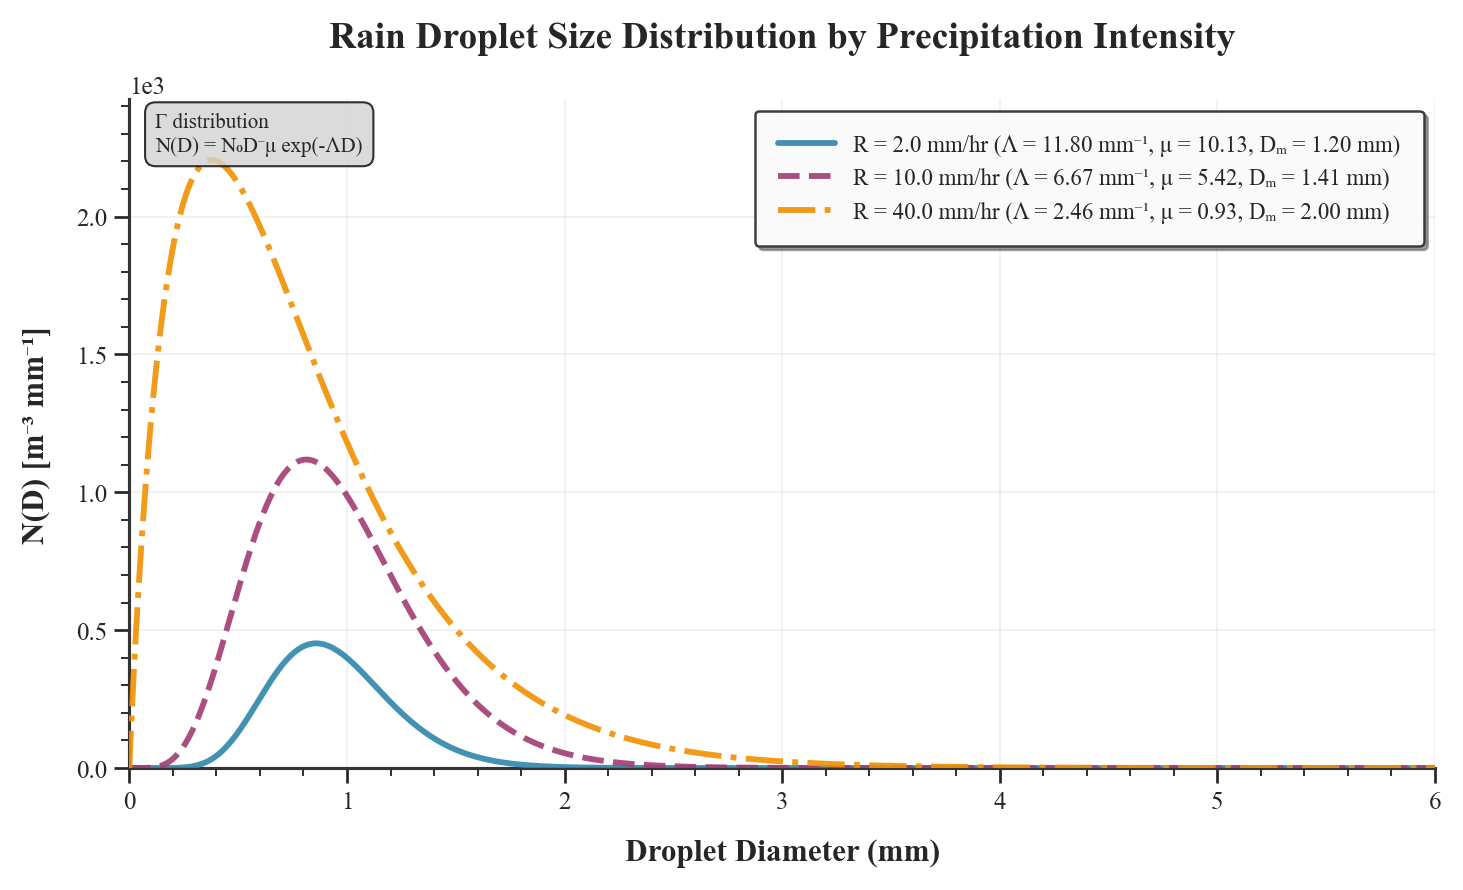

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
D_low = v / 3500
D = np.linspace(0, 0.6, 1000)

# Calculate droplet size distributions
N = 6e4 * np.exp(3.2 * mu_result) * D**(mu_result) * np.exp(-Lambda_result * D)
N_2 = 6e4 * np.exp(3.2 * mu_result2) * D**(mu_result2) * np.exp(-Lambda_result2 * D)
N_3 = 6e4 * np.exp(3.2 * mu_result3) * D**(mu_result3) * np.exp(-Lambda_result3 * D)

# Calculate mean diameters
Dm_1 = (4 + mu_result) / (Lambda_result)
Dm_2 = (4 + mu_result2) / (Lambda_result2)
Dm_3 = (4 + mu_result3) / (Lambda_result3)

# Professional styling configuration
plt.style.use('seaborn-v0_8-whitegrid')  # Better base style
plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman'],
    'axes.linewidth': 1.5,
    'axes.labelsize': 15,
    'axes.titlesize': 17,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid.axis': 'both',
    'grid.alpha': 0.4,
    'grid.linewidth': 0.8
})

# Create figure with golden ratio proportions
fig, ax = plt.subplots(figsize=(10, 6.18))

# Define professional color palette
colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
line_styles = ['-', '--', '-.']

# Plot data with enhanced styling
plots = [
    (D * 10, N / 10, mu_result, Lambda_result/10 , R_input_1 * 3600, Dm_1*10, 0),
    (D * 10, N_2 / 10, mu_result2, Lambda_result2/10, R_input_2 * 3600, Dm_2*10, 1),
    (D * 10, N_3 / 10, mu_result3, Lambda_result3/10, R_input_3 * 3600, Dm_3*10, 2)
]

for x, y, mu, lam, R, Dm, idx in plots:
    ax.plot(x, y,
            linewidth=2.8,
            color=colors[idx],
            linestyle=line_styles[idx],
            alpha=0.9,
            label=f'R = {R:.1f} mm/hr (Λ = {lam:.2f} mm⁻¹, μ = {mu:.2f}, Dₘ = {Dm:.2f} mm)',
            zorder=3)

# Enhanced axis formatting
ax.set_xlabel('Droplet Diameter (mm)', fontweight='bold', labelpad=12)
ax.set_ylabel('N(D) [m⁻³ mm⁻¹]', fontweight='bold', labelpad=12)
ax.set_title('Rain Droplet Size Distribution by Precipitation Intensity',
             fontweight='bold', pad=25, fontsize=18)

# Improved axis limits and scaling
ax.set_xlim(0, max(D * 10))
y_max = max(max(N/10), max(N_2/10), max(N_3/10))
ax.set_ylim(0, y_max * 1.1)

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8, linestyle='-')
ax.set_axisbelow(True)

# Enhanced legend with better positioning
legend = ax.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.95,
    edgecolor='#333333',
    facecolor='white',
    borderpad=1,
    columnspacing=1,
    handlelength=2.5
)
legend.get_frame().set_linewidth(1.2)

# Professional tick formatting
ax.minorticks_on()
ax.tick_params(which='major', length=7, width=1.3, direction='out')
ax.tick_params(which='minor', length=4, width=0.9, direction='out')

# Add subtle border
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#333333')

# Scientific notation for y-axis if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Optimize layout
plt.tight_layout(pad=1.5)

# Optional: Add annotation box with model information
textstr = 'Γ distribution\nN(D) = N₀D⁻μ exp(-ΛD)'
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Display plot
plt.show()

# Reset to default (good practice)
plt.rcParams.update(plt.rcParamsDefault)

In [36]:
Dm_1 = (4+mu_result)/(Lambda_result)
Dm_2 = (4+mu_result2)/(Lambda_result2)
D_m3 = (4+mu_result3)/(Lambda_result3)
print(Dm_1,Dm_2,D_m3)

0.1197422123477151 0.14126200009013365 0.2003330798646374


In [38]:
sum(N*D)/sum(N)*10

0.9431240456269332

In [39]:
sum(N_2*D)/sum(N_2)*10

0.962797897548996

In [40]:
sum(N_3*D)/sum(N_3)*10

0.7849292321205065